<a href="https://colab.research.google.com/github/SusanaGonzales/Personal/blob/main/homework_1/code-Part%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 - Programming Part

**Course:** Deep Learning
**University:** Universidad del Pacifico (UP)
**Instructor:** Alexander Quispe

---

## General instructions

1. This homework covers the topics from **Lectures 1, 2 and 3** (perceptron,
   backpropagation, loss functions, optimizers, regularization), reinforced with
   exercises adapted from the **Caltech Learning From Data Problem Set 4**
   (Yaser S. Abu-Mostafa).
2. The notebook contains **6 exercises** worth a total of **100 points**.
3. Wherever you see `# TODO` or `raise NotImplementedError`, you must write the
   code. Do not delete or alter cells flagged as `# === SETUP - DO NOT MODIFY ===`.
4. Do not change the random `SEED`. Doing so will break the auto-grader.
5. Before submitting:
   - Restart the kernel (`Kernel -> Restart`) and run all cells from top to
     bottom (`Cell -> Run All`). It must run end-to-end without errors.
   - Save the notebook with all outputs visible.
6. Submit the file `Tarea1_code.ipynb` with its original name.

## Point distribution

| Exercise | Topic                                              | Points |
|----------|----------------------------------------------------|--------|
| 1        | OLS vs Gradient Descent (Diabetes)                 | 15     |
| 2        | A single neuron in PyTorch                         | 10     |
| 3        | Manual backpropagation of a 2-layer network        | 20     |
| 4        | MNIST classification (dense, capacity-limited)     | 20     |
| 5        | Optimizer comparison                               | 15     |
| 6        | Dying ReLU + Dropout vs L2                         | 20     |
| **Total**|                                                    | **100**|

## Setup

Run the following cell **once** to import all dependencies. If something is
missing, install with `!pip install <package>`.


In [2]:
# Ejecutar esta celda ANTES del setup
!git clone --depth=1 https://github.com/alexanderquispe/deep-learning-up.git
%cd /content/deep-learning-up/homework_1/code

# Verificación
!pwd
!ls ../data

Cloning into 'deep-learning-up'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 139 (delta 26), reused 116 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 436.32 MiB | 40.60 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Updating files: 100% (123/123), done.
/content/deep-learning-up/homework_1/code
/content/deep-learning-up/homework_1/code
diabetes.csv  synthetic_2d.csv


In [3]:
# === SETUP - DO NOT MODIFY ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths to datasets (relative to this notebook in code/)
DATA_DIR = Path("..") / "data"
assert DATA_DIR.exists(), f"Data folder not found at {DATA_DIR.resolve()}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)


PyTorch: 2.10.0+cu128 | device: cuda


---

# Exercise 1 - OLS vs Gradient Descent on Diabetes  *(15 pts)*

**Context (Lecture 1).** Fit a linear model with **a single feature** (BMI) to
predict one-year diabetes progression. Solve the same problem **two ways** and
compare:

1. **Closed-form OLS**: $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top y$.
2. **Gradient descent from scratch**, starting at $(w_0, b_0) = (0, 0)$, step
   size $\alpha = 0.1$.

> Use **plain `numpy`** (no `sklearn`, no PyTorch in this exercise).

## 1.1 Load and prepare the data *(2 pts)*

Load `diabetes.csv` and build:
- `X_bmi` : array of shape `(n, 1)` with the `bmi` column.
- `y`     : array of shape `(n,)` with the `target` column.


In [4]:
# 1.1 - Load
df = pd.read_csv(DATA_DIR / "diabetes.csv")
print(df.head())
print("Shape:", df.shape)

# TODO: extract X_bmi (shape (n, 1)) and y (shape (n,))
X_bmi = df[["bmi"]].to_numpy()
y = df["target"].to_numpy()

print("X_bmi shape:", X_bmi.shape)
print("y shape:", y.shape)


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
Shape: (442, 11)
X_bmi shape: (442, 1)
y shape: (442,)


## 1.2 Closed-form OLS *(4 pts)*

Implement the closed-form solution. **Augment** `X_bmi` with a column of ones to
include the intercept. Your function must return a 2-vector: `[w_bmi, b]`.

$$
\hat{\boldsymbol{\beta}} \;=\; (X_{\text{aug}}^\top X_{\text{aug}})^{-1}\, X_{\text{aug}}^\top y
$$


In [5]:
# 1.2 - OLS closed form
def ols_closed_form(X, y):
    """Return least-squares coefficients [w, b]."""
    n = X.shape[0]
    ones = np.ones((n, 1))
    X_aug = np.hstack([X, ones])  # columns: [bmi, intercept]

    beta = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    return beta

beta_ols = ols_closed_form(X_bmi, y)
w_ols, b_ols = beta_ols
print(f"OLS -> w = {w_ols:.4f} | b = {b_ols:.4f}")


OLS -> w = 949.4353 | b = 152.1335


## 1.3 Gradient descent from scratch *(6 pts)*

Implement GD that minimizes the **MSE**:

$$
\mathcal{L}(w, b) \;=\; \frac{1}{n}\sum_{i=1}^{n} \big( y_i - (w x_i + b) \big)^2
$$

Per-step updates:

$$
w \leftarrow w - \alpha \, \frac{\partial \mathcal{L}}{\partial w}, \qquad
b \leftarrow b - \alpha \, \frac{\partial \mathcal{L}}{\partial b}
$$

**Fixed configuration (do not change):** $w_0 = 0,\; b_0 = 0,\; \alpha = 0.1,\;$
500 iterations.

Return `w_gd`, `b_gd` and a `loss_history` list (one MSE per iteration).


In [6]:
# 1.3 - Gradient descent
def gradient_descent(X, y, lr=0.1, n_iter=500):
    x = X[:, 0]
    n = len(y)

    w = 0.0
    b = 0.0
    loss_history = []

    for _ in range(n_iter):
        y_hat = w * x + b
        error = y_hat - y

        loss = np.mean(error ** 2)
        loss_history.append(loss)

        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

w_gd, b_gd, loss_hist = gradient_descent(X_bmi, y, lr=0.1, n_iter=500)
print(f"GD -> w = {w_gd:.4f} | b = {b_gd:.4f}")
print("Final loss:", loss_hist[-1])


GD -> w = 192.2774 | b = 152.1335
Final loss: 5188.662985578095


## 1.4 Comparison and visualization *(3 pts)*

(a) Plot the GD **loss curve** (loss vs iteration).
(b) Plot the `(BMI, target)` scatter together with the two fitted lines (OLS and GD).
(c) In a **markdown** cell, briefly answer:
   - Do the two solutions match? Why or why not?
   - What would happen in GD if you used $\alpha = 100$? And $\alpha = 10^{-6}$?


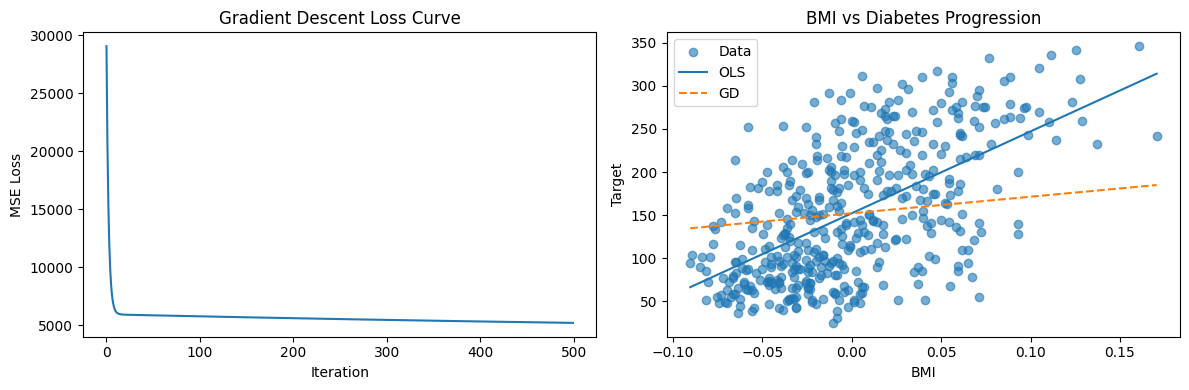

In [7]:
# 1.4 - Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) loss curve
axes[0].plot(loss_hist)
axes[0].set(
    title="Gradient Descent Loss Curve",
    xlabel="Iteration",
    ylabel="MSE Loss"
)

# (b) scatter + two lines
x_plot = np.linspace(X_bmi.min(), X_bmi.max(), 100)
y_ols_plot = w_ols * x_plot + b_ols
y_gd_plot = w_gd * x_plot + b_gd

axes[1].scatter(X_bmi[:, 0], y, alpha=0.6, label="Data")
axes[1].plot(x_plot, y_ols_plot, label="OLS")
axes[1].plot(x_plot, y_gd_plot, linestyle="--", label="GD")
axes[1].set(
    title="BMI vs Diabetes Progression",
    xlabel="BMI",
    ylabel="Target"
)
axes[1].legend()

plt.tight_layout()
plt.show()


**Answer 1.4 (c):**

> Las dos soluciones no coinciden exactamente después de 500 iteraciones. La OLS calcula directamente la solución óptima de mínimos cuadrados, mientras que gradient descent (GD) se acerca al óptimo de manera iterativa. Con la tasa de aprendizaje fija y solo 500 iteraciones, GD todavía puede quedar lejos de los coeficientes exactos de OLS, especialmente en el peso asociado a BMI.

Si la tasa de aprendizaje fuera α = 100, gradient descent probablemente divergiría porque los pasos serían demasiado grandes y sobrepasarían el mínimo. Si la tasa de aprendizaje fuera α = 10^-6, el algoritmo avanzaría extremadamente lento y casi no mejoraría después de 500 iteraciones.


---

# Exercise 2 - A single neuron in PyTorch  *(10 pts)*

**Context (Lecture 1).** Build a sigmoid neuron **by hand** with autograd and
train it with BCE to classify patients into **high** vs **low** diabetes
progression.

> Binary label definition: `y_bin = 1 if target > median(target) else 0`.

## 2.1 Build the binary dataset *(2 pts)*

Use the columns `bmi` and `age` as features, then standardize (zero mean, unit
variance) before passing them to PyTorch.


In [ ]:
# 2.1 - Binary dataset over BMI + AGE
df = pd.read_csv(DATA_DIR / "diabetes.csv")

# TODO: build X (shape (n, 2)) with columns 'bmi' and 'age', and y (shape (n,))
# binary using the median of 'target'.
X = None
y = None

# Standardize X (important for sigmoid)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Convert to tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)
print("X_t:", X_t.shape, "| y_t:", y_t.shape, "| positive rate:", y_t.mean().item())

raise NotImplementedError("Complete 2.1")


## 2.2 Define the neuron and the forward pass *(3 pts)*

A single sigmoid neuron:

$$
\hat{y} \;=\; \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}
$$

Initialize `w` and `b` with `torch.zeros(..., requires_grad=True)`. **Do NOT
use `nn.Linear`** in this exercise: the goal is to handle `requires_grad`
tensors explicitly.


In [ ]:
# 2.2 - Parameters and manual forward pass
torch.manual_seed(SEED)

# TODO: create w (shape (2,)) and b (shape (1,)) as torch tensors with requires_grad=True
w = None
b = None

def forward(X):
    \"\"\"Return sigmoid(X @ w + b), shape (n,).\"\"\"
    # TODO
    raise NotImplementedError("Complete forward")

# Sanity check (will only run after you complete the cell above)
y_hat0 = forward(X_t)
print("Initial y_hat:", y_hat0[:5].detach().numpy())


## 2.3 BCE loss and training loop *(5 pts)*

Implement **binary cross-entropy** explicitly (do **not** use
`F.binary_cross_entropy`):

$$
\mathcal{L} \;=\; -\frac{1}{n}\sum_{i=1}^{n}\Big[\, y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \Big]
$$

Add a small epsilon (`1e-7`) inside the logs to avoid `log(0)`.

Then write a training loop **by hand** (no `torch.optim`) for 500 epochs with
$\alpha = 0.1$. Per step:

```python
loss.backward()
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
```

Report the final **accuracy** on the dataset (threshold 0.5) and plot the loss
curve.


In [ ]:
# 2.3 - BCE + manual training loop
def bce(y_hat, y):
    \"\"\"Mean binary cross-entropy.\"\"\"
    eps = 1e-7
    # TODO
    raise NotImplementedError("Complete bce")

# TODO: write the training loop (500 epochs, lr=0.1) using forward, bce,
# loss.backward() and the manual SGD update shown above.
# After training, compute accuracy with threshold 0.5 and plot the loss curve.
raise NotImplementedError("Complete the training loop")


---

# Exercise 3 - Manual backpropagation of a 2-layer network  *(20 pts)*

**Context (Lecture 2).** So far you used autograd. Now you must implement
**the backward pass by hand** on a 2D non-linearly-separable dataset (spirals).

Architecture:
- Input: $\mathbf{x} \in \mathbb{R}^2$
- Hidden layer: 16 units + **tanh** activation
  $\mathbf{h} = \tanh(W_1 \mathbf{x} + \mathbf{b}_1)$
- Output layer: 1 unit + **sigmoid**
  $\hat{y} = \sigma(\mathbf{w}_2^\top \mathbf{h} + b_2)$
- Loss: BCE

**Do NOT use autograd in 3.2 - 3.4.** Use only `numpy`.

## 3.1 Load and visualize the dataset *(2 pts)*

Setup is provided. Read it carefully so you understand what `X_tr` and `X_te`
look like.


In [ ]:
# 3.1 - Load spirals (provided)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = df[["x1", "x2"]].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.float32)

# 80/20 split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(y))
n_train = int(0.8 * len(y))
tr, te = idx[:n_train], idx[n_train:]
X_tr, y_tr = X[tr], y[tr]
X_te, y_te = X[te], y[te]

plt.figure(figsize=(5,5))
plt.scatter(X_tr[y_tr==0,0], X_tr[y_tr==0,1], s=10, label="class 0")
plt.scatter(X_tr[y_tr==1,0], X_tr[y_tr==1,1], s=10, label="class 1")
plt.legend(); plt.title("Spirals (train)"); plt.gca().set_aspect("equal"); plt.show()


## 3.2 Forward pass *(4 pts)*

Implement a forward pass that returns both $\hat{y}$ and the **intermediate
activations** required for the backward pass (cache).

The parameter initialization helper and the sigmoid are provided.


In [ ]:
# 3.2 - Init + forward
def init_params(input_dim=2, hidden_dim=16, seed=SEED):
    \"\"\"Xavier-ish initialization for tanh networks. Provided.\"\"\"
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, np.sqrt(1.0 / input_dim),  (hidden_dim, input_dim)).astype(np.float32)
    b1 = np.zeros(hidden_dim, dtype=np.float32)
    W2 = rng.normal(0, np.sqrt(1.0 / hidden_dim), (1, hidden_dim)).astype(np.float32)
    b2 = np.zeros(1, dtype=np.float32)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, params):
    \"\"\"X shape (N, 2). Return (y_hat, cache).\"\"\"
    # TODO: compute z1 = X @ W1.T + b1, h = tanh(z1),
    #       z2 = h @ W2.T + b2, y_hat = sigmoid(z2).squeeze(-1)
    # Build cache = {"X": X, "z1": z1, "h": h, "z2": z2}
    raise NotImplementedError("Complete forward")


## 3.3 Backward pass *(8 pts)*

Compute gradients with the chain rule. Use these identities (sigmoid + BCE
combine nicely):

- $\dfrac{\partial \mathcal{L}}{\partial z_2} = \hat{y} - y$
- $\dfrac{\partial \mathcal{L}}{\partial W_2} = \dfrac{1}{N} \delta_2^\top \mathbf{h}$
- $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}_2} = \dfrac{1}{N} \mathbf{1}^\top \delta_2$
- $\delta_1 = (\delta_2 W_2) \odot (1 - \mathbf{h}^2)$  *(tanh derivative)*
- $\dfrac{\partial \mathcal{L}}{\partial W_1} = \dfrac{1}{N} \delta_1^\top X$
- $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}_1} = \dfrac{1}{N} \mathbf{1}^\top \delta_1$

where $\delta_2$ has shape `(N, 1)` and $\delta_1$ has shape `(N, H)`.


In [ ]:
# 3.3 - Backward pass
def backward(y, cache, params):
    \"\"\"Return dict with gradients dW1, db1, dW2, db2.\"\"\"
    # TODO
    raise NotImplementedError("Complete backward")


## 3.4 Training loop and evaluation *(4 pts)*

Train for 2000 epochs full-batch with $\alpha = 0.1$. Report **train and test
accuracy**. Plot the training loss curve.

You must write the training loop yourself: forward -> compute BCE loss ->
backward -> update each parameter with `params[k] -= lr * grads[k]`.


In [ ]:
# 3.4 - Manual training loop
# TODO: implement the loop. After training, compute and print:
#   - final train loss
#   - train accuracy and test accuracy (threshold 0.5 on y_hat)
# and plot the loss curve.
raise NotImplementedError("Complete the training loop")


## 3.5 Decision boundary *(2 pts)*

Plot the decision boundary learned by your network on the **training** set.

Hint: build a meshgrid over the input space, run `forward` on the flattened
grid, reshape to image dimensions, and use `plt.contourf`.


In [ ]:
# 3.5 - Decision boundary
# TODO: produce a contourf plot of the predicted probabilities over a 2D grid
# spanning the data range, with the training points overlaid by class.
raise NotImplementedError("Complete the decision boundary plot")


---

# Exercise 4 - MNIST classification with dense networks  *(20 pts)*

**Context (Caltech Sec. 2 + Lecture 2).** Build two dense models for MNIST and
report test accuracy. Constraints:

- Allowed layers only: `nn.Linear`, `nn.ReLU`, `nn.Softmax`, `nn.Dropout`.
- Loss: cross-entropy. Optimizer: Adam with `lr=1e-3`. Epochs: 5. Batch size: 64.
- Normalize pixel values by dividing by 255 (already handled by `ToTensor`).

| Sub-exercise | Restriction                            | Min accuracy | Pts |
|--------------|----------------------------------------|--------------|-----|
| 4.A          | <= 100 hidden units                    | 0.97         | 8   |
| 4.B          | <= 200 hidden units, >= 2 hidden layers| 0.98         | 8   |
| 4.C          | Discussion                             |              | 4   |

> Use GPU if available. On CPU each model trains in under 3 minutes.

## 4.0 Load MNIST (provided)


In [ ]:
# 4.0 - Load MNIST via torchvision (caches it inside data/)
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root=str(DATA_DIR), train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root=str(DATA_DIR), train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print("Train:", len(train_ds), "| Test:", len(test_ds))
print("Image shape:", train_ds[0][0].shape, "| label:", train_ds[0][1])


## 4.1 Train / eval helpers (provided)

You may use these as-is. Read them so you know what they do.


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.view(xb.size(0), -1)  # flatten 28x28 -> 784
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.view(xb.size(0), -1)
        logits = model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
    return correct / len(loader.dataset)


## 4.A Model with <= 100 hidden units *(8 pts)*

Build a `nn.Sequential` mapping **784** features to **10** logits.
**Constraint:** total hidden units summed across hidden layers <= 100.

Train for 5 epochs and report the best test accuracy. Target: >= 0.97.


In [ ]:
# 4.A - Small model
torch.manual_seed(SEED)

# TODO: build model_A (constraint: <= 100 hidden units total)
model_A = None

# TODO: move to device, create the Adam optimizer (lr=1e-3) and CrossEntropyLoss,
# train for 5 epochs using train_one_epoch + evaluate, and print the best test acc.
raise NotImplementedError("Complete 4.A")


## 4.B Model with <= 200 hidden units and >= 2 hidden layers *(8 pts)*

Same training setup, but now with **at least two hidden layers** and **at most
200 hidden units total**. You may add `Dropout` if you wish.

Target: best test accuracy >= 0.98.


In [ ]:
# 4.B - Medium model
torch.manual_seed(SEED)

# TODO: build model_B (>= 2 hidden layers, <= 200 hidden units total)
model_B = None

# TODO: train for 5 epochs and print the best test acc.
raise NotImplementedError("Complete 4.B")


## 4.C Discussion *(4 pts)*

Answer in a **markdown** cell:

1. What is the gap between A and B? How much do you gain by doubling capacity?
2. Is the jump explained by **parameter count** or by **depth**?
   (Hint: count parameters with `sum(p.numel() for p in model.parameters())`.)
3. If the limit were only **30 hidden units**, would you still hit >= 0.95?
   What technique would you try?


**Answer 4.C:**

> *Write your discussion here.*


---

# Exercise 5 - Optimizer comparison  *(15 pts)*

**Context (Lectures 2 and 3).** On the spirals dataset (`synthetic_2d.csv`)
and a **fixed** `2 -> 32 -> 32 -> 1` MLP with ReLU activations, compare four
optimizers:

- SGD (no momentum)
- SGD + Momentum (`momentum=0.9`)
- RMSProp
- Adam

Same `lr=1e-2`, same init (`torch.manual_seed(SEED)` before building the
model), same number of epochs (200), same batch size (32).

## 5.1 Define the model and the training function *(5 pts)*


In [ ]:
# 5.1 - Setup (data loading + dataloader is provided)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = torch.tensor(df[["x1","x2"]].to_numpy(), dtype=torch.float32)
y = torch.tensor(df["label"].to_numpy(),     dtype=torch.float32)

ds = TensorDataset(X, y)
loader = DataLoader(ds, batch_size=32, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define 2 -> 32 -> 32 -> 1 with ReLU on hidden layers
        raise NotImplementedError("Complete MLP.__init__")

    def forward(self, x):
        # TODO
        raise NotImplementedError("Complete MLP.forward")

def train_optim(opt_name, n_epochs=200, lr=1e-2):
    \"\"\"Train an MLP with the chosen optimizer. Return list of per-epoch losses.\"\"\"
    # TODO: seed torch, build the MLP, build BCEWithLogitsLoss,
    # build the optimizer that matches opt_name (SGD / SGD+Momentum / RMSProp / Adam),
    # run the training loop and return the loss history.
    raise NotImplementedError("Complete train_optim")


## 5.2 Train the four optimizers and plot *(6 pts)*


In [ ]:
# 5.2 - Train + plot
# TODO: train all four optimizers, store the loss histories in a dict,
# and plot the four curves on the same figure.
raise NotImplementedError("Complete 5.2")


## 5.3 Discussion *(4 pts)*

Answer in markdown:
1. Which one converges fastest in terms of epochs? Which one ends with the
   lowest loss?
2. Plain SGD lags behind: why? (Use what you saw about adaptive learning rates.)
3. If the dataset were huge (millions of samples), would you still pick Adam?
   Why?


**Answer 5.3:**

> *Write your discussion here.*


---

# Exercise 6 - Dying ReLU + Dropout vs L2  *(20 pts)*

This exercise has **two independent parts**.

## Part A - The Dying ReLU problem  *(10 pts)*

**Context (Caltech Sec. 1, Problem C).** When training with SGD **without
shuffling** and the batch sees **all negative examples first**, then all
positives, ReLU units can "die": their pre-activations become negative for
almost every example and the gradient is zero forever. We will reproduce this.

### 6.A.1 Build a simple binary dataset (provided)


In [ ]:
# 6.A.1 - Gaussian binary dataset, 2 well-separated classes (provided)
rng = np.random.default_rng(SEED)
N = 500

X_neg = rng.normal(loc=-2.0, scale=1.0, size=(N, 10)).astype(np.float32)
X_pos = rng.normal(loc=+2.0, scale=1.0, size=(N, 10)).astype(np.float32)

# IMPORTANT: ORDERED stack - all negatives first, then all positives.
X = np.vstack([X_neg, X_pos])
y = np.hstack([np.zeros(N), np.ones(N)]).astype(np.float32)

X_t = torch.tensor(X); y_t = torch.tensor(y)
print("X:", X_t.shape, "| y:", y_t.shape)


### 6.A.2 Train WITHOUT shuffling *(4 pts)*

Build a `10 -> 64 -> 64 -> 1` ReLU network. Train with SGD (`lr=0.1`,
30 epochs) **with `shuffle=False`** and batch size 32.

After training, count how many hidden units are **dead**.

> A unit is **dead** if its ReLU output is exactly `0` for **every** example
> in the dataset.


In [ ]:
# 6.A.2 - Network + training + dead-neuron diagnostic
torch.manual_seed(SEED)

class ReluNet(nn.Module):
    def __init__(self, in_dim=10, h=64):
        super().__init__()
        # TODO: build 10 -> 64 -> 64 -> 1 with ReLU; keep references so you can
        # inspect each hidden activation in 'hidden_activations' below.
        raise NotImplementedError("Complete ReluNet.__init__")

    def forward(self, x):
        # TODO
        raise NotImplementedError("Complete ReluNet.forward")

    def hidden_activations(self, x):
        \"\"\"Return (h1, h2): post-ReLU activations of each hidden layer.\"\"\"
        # TODO
        raise NotImplementedError("Complete hidden_activations")

def count_dead(model, X_t):
    \"\"\"Return (dead_units_layer1, dead_units_layer2).\"\"\"
    # TODO: run hidden_activations on the entire dataset; a unit is dead if
    # its activation is 0 for every sample. (Tip: use the per-column max.)
    raise NotImplementedError("Complete count_dead")

def train_run(shuffle):
    \"\"\"Train one ReluNet with the given shuffle flag and return the trained model.\"\"\"
    # TODO: seed torch, build the model, SGD (lr=0.1) + BCEWithLogitsLoss,
    # build a DataLoader with the requested shuffle flag (batch_size=32),
    # and train for 30 epochs.
    raise NotImplementedError("Complete train_run")

model_no_shuffle = train_run(shuffle=False)
d1, d2 = count_dead(model_no_shuffle, X_t)
print(f"NO shuffle  ->  dead units L1: {d1}/64,  L2: {d2}/64")


### 6.A.3 Train WITH shuffling and compare *(4 pts)*


In [ ]:
# 6.A.3 - Same setup, shuffle=True
model_shuffle = train_run(shuffle=True)
d1, d2 = count_dead(model_shuffle, X_t)
print(f"WITH shuffle ->  dead units L1: {d1}/64,  L2: {d2}/64")


### 6.A.4 Discussion *(2 pts)*

Answer in markdown:
- Why does data ordering kill ReLU units?
- What concrete mechanism inside SGD produces the phenomenon?
- Why does shuffling mitigate it?

**Answer 6.A.4:**

> *Write your explanation here.*


## Part B - Dropout vs L2  *(10 pts)*

On the spirals dataset, compare three trainings of the **same** MLP
`2 -> 64 -> 64 -> 1` (ReLU, 200 epochs, Adam `lr=1e-3`):

1. **No regularization** (baseline)
2. **Dropout** (p=0.3 between hidden layers)
3. **L2** (`weight_decay=1e-2` in Adam)

For each, report **train loss and validation loss** at the end, and plot the
three validation-loss curves on a single figure.


In [ ]:
# 6.B - Dropout vs L2 (data split provided; the rest is up to you)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = df[["x1","x2"]].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.float32)

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(y))
n_tr = int(0.7 * len(y))
tr, va = idx[:n_tr], idx[n_tr:]

X_tr = torch.tensor(X[tr]); y_tr = torch.tensor(y[tr])
X_va = torch.tensor(X[va]); y_va = torch.tensor(y[va])
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

# TODO:
#  1. Implement a function `make_model(use_dropout: bool) -> nn.Sequential` that
#     builds 2 -> 64 -> ReLU -> [Dropout(0.3)?] -> 64 -> ReLU -> [Dropout(0.3)?] -> 1
#  2. Implement a function `run(name, use_dropout, weight_decay) -> list[float]`
#     that trains for 200 epochs, returning the per-epoch validation loss.
#  3. Run three configurations: baseline, dropout=True, weight_decay=1e-2
#  4. Plot the three validation-loss curves on the same figure.
raise NotImplementedError("Complete 6.B")


**Answer 6.B (markdown):**

1. Which of the three options generalizes best on this dataset?
2. Why can dropout **raise** the train loss while **lowering** the val loss?
3. If you had to pick only one (dropout or L2) for a much deeper network, which
   would you try first? Why?

> *Write your discussion here.*

---

# End of Homework 1 - Programming Part

Before submitting:
- [ ] Did you restart the kernel and run everything from scratch?
- [ ] Do all cells show output (plots included)?
- [ ] Is the file named `Tarea1_code.ipynb`?
- [ ] Are there no remaining `raise NotImplementedError` cells?
